In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/sim46.pkl", "rb") as f:
    all_results = pickle.load(f)

with open("/home/fr/fr_lr554/samplefactory/sample-factory/sf_workingdir_lilly/dmlab/analysis/data/mc_measureslora46.pkl", "rb") as f:
    mc_measures = pickle.load(f)

In [3]:
print(all_results.keys())
print(all_results[2222].keys())
print(mc_measures.keys())

dict_keys([2222, 3333, 4444, 5555])
dict_keys(['raw_score', 'lenweighted_score', 'reward_min', 'len'])
dict_keys(['orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])


In [4]:
weight_trials = [0]
n_seeds = 4
seeds = [2222, 3333, 4444, 5555]
n_policies = 4

sorted_weight_trials = sorted(weight_trials)

time_interval = [80000000,100000000]

In [5]:
'''
data structure all_results:
dictionary with the seeds as keys
{2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
'''

"\ndata structure all_results:\ndictionary with the seeds as keys\n{2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, \n                3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, \n                4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},\n                5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}\n"

In [6]:


mean_results_by_seeds = {2222:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
            3333:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}, 
            4444:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None},
            5555:{'raw_score':None, 'lenweighted_score':None, 'reward_min':None, 'len':None}}
for seed in seeds:
    mean_results_by_seeds[seed]['raw_score'] = all_results[seed]['raw_score'].mean(axis=1)
    mean_results_by_seeds[seed]['lenweighted_score'] = all_results[seed]['lenweighted_score'].mean(axis=1)
    mean_results_by_seeds[seed]['reward_min'] = all_results[seed]['reward_min'].mean(axis=1)
    mean_results_by_seeds[seed]['len'] = all_results[seed]['len'].mean(axis=1)
    



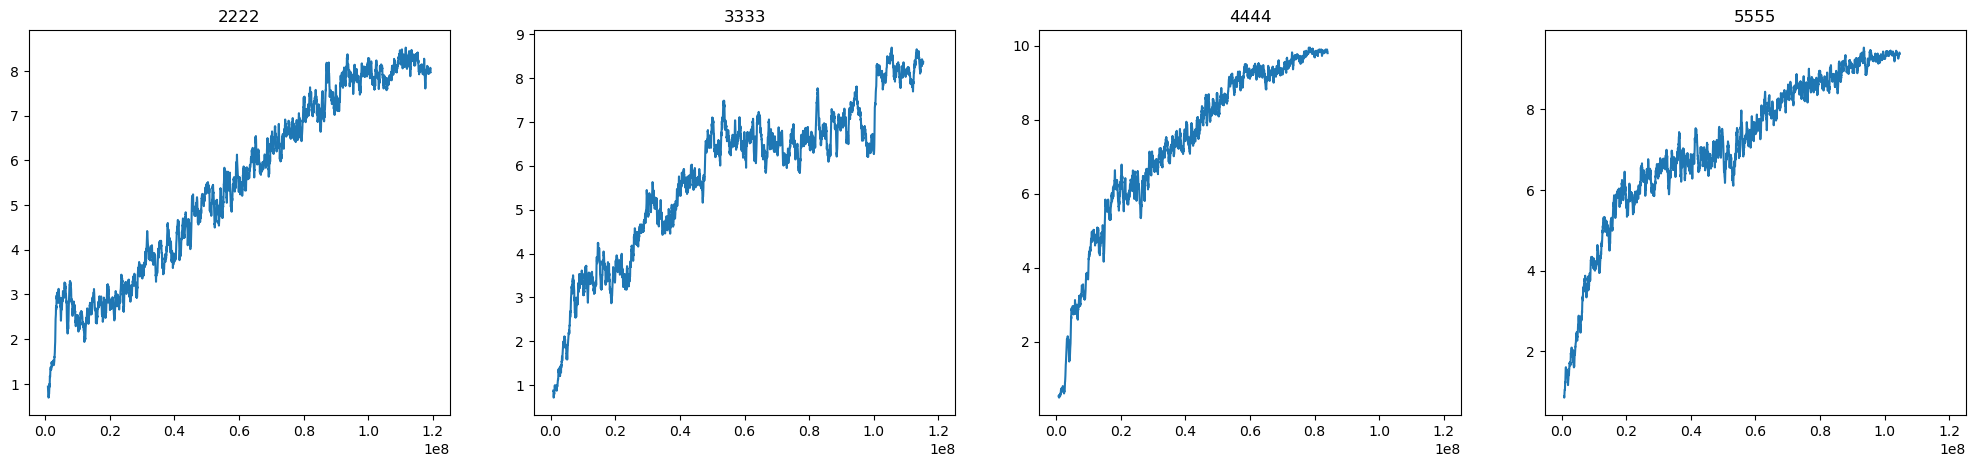

In [7]:
# plot the raw score curves for all weight trials & policies
'''
fig, ax = plt.subplots(7,5, figsize=(25,40), sharex=True)
for i,t in enumerate(weight_trials):
    for policy in range(n_policies):
        raw_score = mean_results[t][policy][f'{policy}/policy_stats/avg_z_00_openfield_map2_fixed_loc3_dmlab_raw_score']
        idx = all_results[t][policy].index.to_list()
        ax[i//5, i%5].plot(idx, raw_score)
        ax[i//5, i%5].set_title(f'{t}')
'''

fig, ax = plt.subplots(1,4, figsize=(25,5), sharex=True)
for i,seed in enumerate(seeds):
    raw_score = mean_results_by_seeds[seed]['raw_score']
    idx = mean_results_by_seeds[seed]['raw_score'].index.to_list()
    ax[i].plot(idx, raw_score)
    ax[i].set_title(f'{seed}')

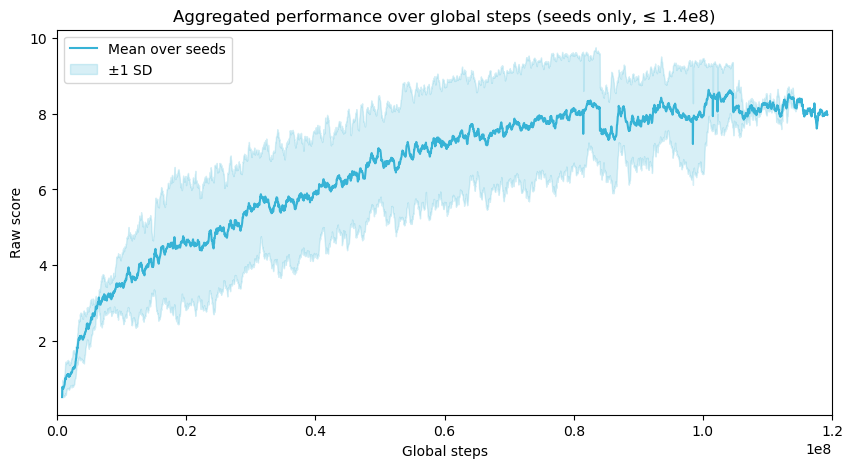

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Sammle alle Seed-Kurven in ein gemeinsames DataFrame
records = []
for seed in seeds:
    s = mean_results_by_seeds[seed]["raw_score"]  # pd.Series: index=global_step, values=raw_score
    df = s.rename("raw_score").reset_index()
    df.columns = ["global_step", "raw_score"]
    df["seed"] = seed
    records.append(df)

all_df = pd.concat(records, ignore_index=True)

# nur bis 1.4e8
max_step = 1.2e8
all_df = all_df[all_df["global_step"] <= max_step]

# Aggregation über alle Seeds pro global_step:
agg = (all_df
       .groupby("global_step")["raw_score"]
       .agg(mean="mean", std="std", n="count")
       .reset_index()
       .sort_values("global_step"))

x = agg["global_step"].to_numpy()
y = agg["mean"].to_numpy()
sd = agg["std"].to_numpy()

color = "#37B3D6"

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, y, color=color, label="Mean over seeds")
ax.fill_between(x, y - sd, y + sd, color=color, alpha=0.2, label="±1 SD")

ax.set_xlim(0, max_step)
ax.set_xlabel("global steps")
ax.set_ylabel("raw performance score")
ax.set_title("Aggregated performance over global steps (seeds only, ≤ 1.4e8)")
ax.legend()
plt.show()


In [9]:
# take the mean of a metric for the relevant time interval

mean_raw_score_time_interval = []
for seed in seeds:
    raw_score = mean_results_by_seeds[seed]['raw_score']
    raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]
    mean_raw_score_time_interval.append(raw_score_time_interval.mean())

/tmp/ipykernel_2379722/2443133274.py:6: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  raw_score_time_interval = raw_score[time_interval[0]:time_interval[1]]


#### homemade MC measures

In [10]:
print(mc_measures.keys())

dict_keys(['orth_vec_thresh_crossed', 'orth_vec_thresh_crossed_not_norm', 'norm_thresh_crossed', 'summed_MC_svd', 'MC_singular_components_svd', 'MC_singular_components_hs_svd', 'participation_ratio_svd'])


In [11]:
print(mc_measures['orth_vec_thresh_crossed'])
print(mean_raw_score_time_interval)

[70, 70, 70, 70]
[7.5605251987101685, 6.859526978934774, 9.834077899194504, 9.03861196017446]


Text(0, 0.5, 'performance - mean raw score')

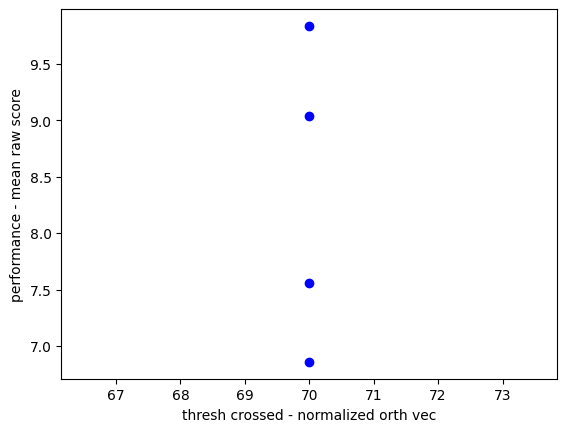

In [12]:
plt.figure()
plt.scatter(mc_measures['orth_vec_thresh_crossed'], mean_raw_score_time_interval, c='b')
plt.xlabel('thresh crossed - normalized orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

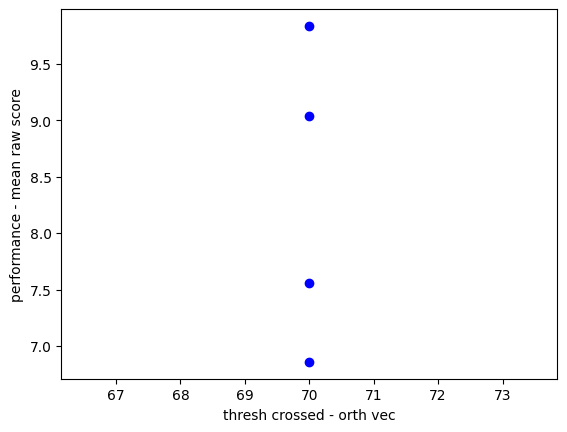

In [13]:
plt.figure()
plt.scatter(mc_measures['orth_vec_thresh_crossed_not_norm'], mean_raw_score_time_interval, c='b')
plt.xlabel('thresh crossed - orth vec')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

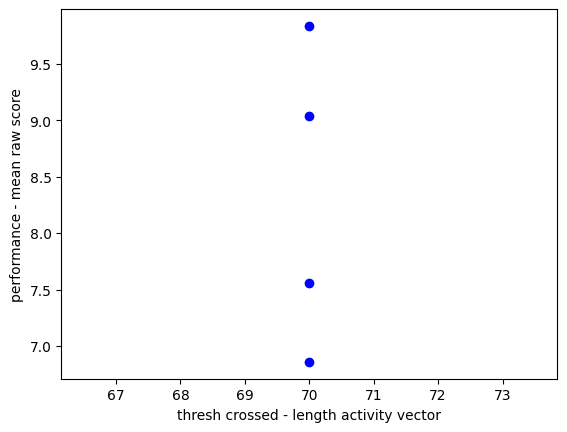

In [14]:
plt.figure()
plt.scatter(mc_measures['norm_thresh_crossed'], mean_raw_score_time_interval, c='b')
plt.xlabel('thresh crossed - length activity vector')
plt.ylabel('performance - mean raw score')

#### Giovanni et.al., SVD, participation ratio

Text(0, 0.5, 'performance - mean raw score')

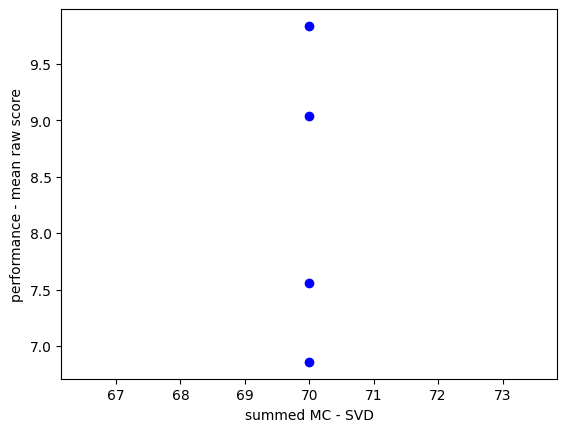

In [15]:
plt.figure()
plt.scatter(mc_measures['summed_MC_svd'], mean_raw_score_time_interval, c='b')
plt.xlabel('summed MC - SVD')
plt.ylabel('performance - mean raw score')

In [17]:
np.argmax(mc_measures['summed_MC_svd'])

2

Text(0, 0.5, 'performance - mean raw score')

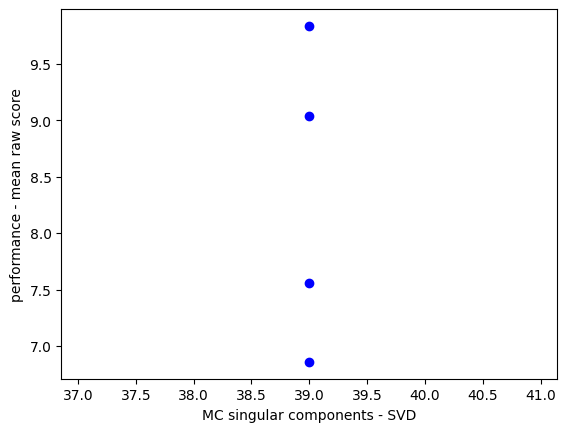

In [16]:
plt.figure()
plt.scatter(mc_measures['MC_singular_components_svd'], mean_raw_score_time_interval, c='b')
plt.xlabel('MC singular components - SVD')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

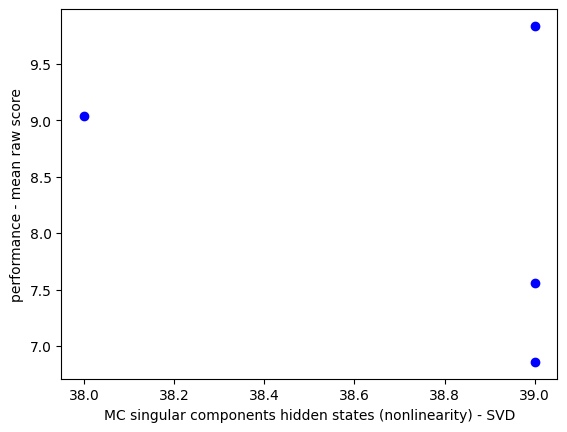

In [17]:
plt.figure()
plt.scatter(mc_measures['MC_singular_components_hs_svd'], mean_raw_score_time_interval, c='b')
plt.xlabel('MC singular components hidden states (nonlinearity) - SVD')
plt.ylabel('performance - mean raw score')

Text(0, 0.5, 'performance - mean raw score')

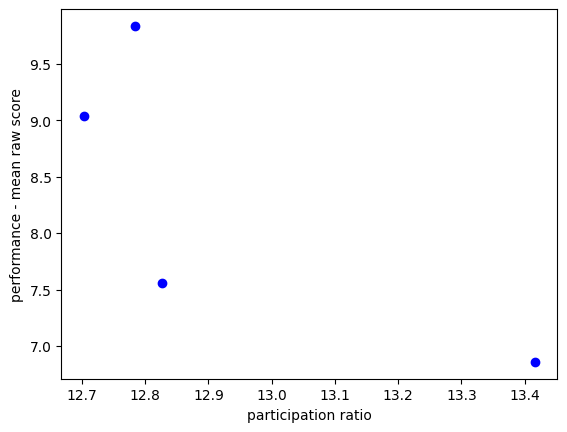

In [18]:
plt.figure()
plt.scatter(mc_measures['participation_ratio_svd'], mean_raw_score_time_interval, c='b')
plt.xlabel('participation ratio')
plt.ylabel('performance - mean raw score')